# Benchmark: apatite fission track annealing against Ketcham (2005)

Ketcham, R. A. (2005), *Forward and Inverse Modeling of Low-Temperature Thermochronometry Data*, Reviews in Mineralogy and Geochemistry 58, 275-314, Figure 7, shows four synthetic time-temperature histories used to illustrate the behaviour of the apatite fission track (AFT) forward model: fast cooling, constant cooling, reheating, and cooling at two different rates evaluated for two different Dpar (annealing kinetics) values.

This notebook reconstructs these four histories, feeds them into PyBasin's own AFT annealing code (`lib.AFTannealingLib.simulate_AFT_annealing`), and compares the resulting ages against reference ages read from the published figure. Figure 7 only shows track length density plots, not numeric mean track lengths, so no length comparison is made here.

## Sourcing the thermal histories and reference values

The time-temperature series reproduce the four panels of Figure 7 as closely as the piecewise linear segments described in the text and figure allow. The reference ages are read directly from Figure 7 for each history.

PyBasin's `AFTannealingLib.calculate_reduced_track_lengths` implements the Ketcham et al. (2007) model (Table 5c constants, the default in HeFTy), which fixes an equation shape parameter, beta, at -1. Figure 7 of Ketcham (2005) was generated with the earlier Ketcham et al. (1999) fanning curvilinear model, which keeps beta as a free, separately fitted parameter (about -12); these are not the same functional form. Because of this, `lib/AFTannealingLib.py` now also implements a genuine Ketcham et al. (1999) free beta annealing model, selected with `method='Ketcham2000'` in `simulate_AFT_annealing` (the name matches the AFTSolve program of Ketcham et al. (2000), which implements the same 1999 kinetics).

## Import modules

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from lib import AFTannealingLib as aft

## The four thermal histories

Each history below is reconstructed from the piecewise linear time-temperature segments shown in Figure 7. Times are in Ma before present (descending, ending at 0) and temperatures in degrees Celsius, matching Ketcham (2005) Figure 7:

- **7a, fast cooling**: rapid initial cooling from 190 to 35 degrees C over 4 Myr, then slow cooling from 35 to 20 degrees C over the remaining 89 Myr.
- **7b, constant cooling**: linear cooling from 190 to 20 degrees C over the full 93 Myr.
- **7c, reheating**: cooling from 190 to 20 degrees C over 13 Myr, reheating back up to 90 degrees C over the next 42 Myr, then final cooling to 20 degrees C over the last 38 Myr.
- **7d, two cooling rates**: cooling from 190.0 to 120.0 degrees C over 12 Myr, a slower cooling stage from 120.0 to 100.0 degrees C over 70.0 Myr, then final cooling to 20 degrees C over the last 11.0 Myr. Evaluated twice, for Dpar of 1.75 and 2.50 micrometre, since this history is designed to show how a more annealing-resistant apatite (higher Dpar) can partially retain an older, inherited age component through a moderate reheating that fully resets a less resistant apatite.

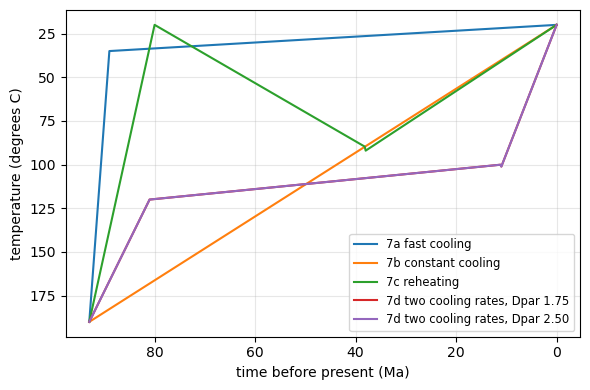

In [2]:
def build_history_7a():
    initial_temps = np.linspace(190.0, 35, 20, endpoint=False)
    initial_tsteps = np.linspace(93.0, 89, 20, endpoint=False)
    second_temps = np.linspace(35.0, 20, 96 * 5, endpoint=True)
    second_tsteps = np.linspace(89, 0, 96 * 5, endpoint=True)
    temps = np.concatenate((initial_temps, second_temps))
    tsteps = np.concatenate((initial_tsteps, second_tsteps))
    return tsteps, temps


def build_history_7b():
    temps = np.linspace(190.0, 20, 500, endpoint=True)
    tsteps = np.linspace(93, 0, 500, endpoint=True)
    return tsteps, temps


def build_history_7c():
    first_temps = np.linspace(190.0, 20.0, 11 * 5, endpoint=False)
    first_tsteps = np.linspace(93.0, 80.0, 11 * 5, endpoint=False)
    second_temps = np.linspace(20.0, 90.0, 45 * 5, endpoint=False)
    second_tsteps = np.linspace(80.0, 38.0, 45 * 5, endpoint=False)
    third_temps = np.linspace(92.0, 20.0, 43 * 5, endpoint=True)
    third_tsteps = np.linspace(38.0, 0, 43 * 5, endpoint=True)
    temps = np.concatenate((first_temps, second_temps, third_temps))
    tsteps = np.concatenate((first_tsteps, second_tsteps, third_tsteps))
    return tsteps, temps


def build_history_7d():
    initial_temps = np.linspace(190.0, 120.0, 13 * 5, endpoint=False)
    initial_tsteps = np.linspace(93.0, 81.0, 13 * 5, endpoint=False)
    second_temps = np.linspace(120.0, 100.0, 75 * 5, endpoint=False)
    second_tsteps = np.linspace(81.0, 11.0, 75 * 5, endpoint=False)
    third_temps = np.linspace(101.1, 20.0, 13 * 5, endpoint=True)
    third_tsteps = np.linspace(11.0, 0, 13 * 5, endpoint=True)
    temps = np.concatenate((initial_temps, second_temps, third_temps))
    tsteps = np.concatenate((initial_tsteps, second_tsteps, third_tsteps))
    return tsteps, temps


histories = {
    '7a fast cooling': (build_history_7a, 1.75),
    '7b constant cooling': (build_history_7b, 1.75),
    '7c reheating': (build_history_7c, 1.75),
    '7d two cooling rates, Dpar 1.75': (build_history_7d, 1.75),
    '7d two cooling rates, Dpar 2.50': (build_history_7d, 2.50),
}

fig, ax = plt.subplots(figsize=(6, 4))
for name, (builder, _) in histories.items():
    tsteps_age, temps_c = builder()
    ax.plot(tsteps_age, temps_c, label=name)
ax.set_xlabel('time before present (Ma)')
ax.set_ylabel('temperature (degrees C)')
ax.invert_xaxis()
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3)
fig.tight_layout()

ax.invert_yaxis()

## Reference ages from Ketcham (2005), Figure 7

In [3]:
reference = {
    '7a fast cooling': dict(age=89.4),
    '7b constant cooling': dict(age=39.9),
    '7c reheating': dict(age=64.7),
    '7d two cooling rates, Dpar 1.75': dict(age=13.5),
    '7d two cooling rates, Dpar 2.50': dict(age=52.3),
}

## Run PyBasin's AFT annealing model

`simulate_AFT_annealing` is the function `run_burial_hist_model` in `lib/pybasin_lib.py` calls for every AFT sample. `method='Ketcham2000'` uses the newly added implementation of the Ketcham et al. (1999) model, with beta as a free parameter, matching the model used to generate Figure 7.

`kinetic_parameter='Dpar'` is used with the same Dpar values as the reference; the Ketcham (1999, 2000) Dpar to rmr0 (and initial track length) conversion is used automatically for this method. `apply_c_axis_correction=True` is used, following the c-axis projection convention standard in HeFTy. The Ketcham (1999, 2000) model predates the c-axis projection technique entirely, so it has no separate uncorrected calibration, and (found while building this notebook) its raw reduced length is already the c-axis projected quantity; the projection step `caxis_project_reduced_lengths` that the Ketcham (2007) model applies is skipped for `method='Ketcham2000'`, otherwise the reported lengths come out systematically too short.

`method='Ketcham2000'` always uses the pure Python (numba-compiled) path, since no compiled Fortran implementation of the free beta model exists; `use_fortran_algorithm` is ignored for this method.

## Verifying the pure Python fallback fix

Confirms `use_fortran_algorithm=False` now matches `use_fortran_algorithm=True` exactly, with no `NaN`, for every history and Dpar value used in this notebook.

In [4]:
for name, (builder, dpar) in histories.items():
    tsteps_age, temps_c = builder()
    timesteps = tsteps_age.max() - tsteps_age

    age_fortran = aft.simulate_AFT_annealing(
        timesteps, temps_c, dpar, kinetic_parameter='Dpar',
        apply_c_axis_correction=True, use_fortran_algorithm=True,
        surpress_resampling=False)[1]
    age_python = aft.simulate_AFT_annealing(
        timesteps, temps_c, dpar, kinetic_parameter='Dpar',
        apply_c_axis_correction=True, use_fortran_algorithm=False,
        surpress_resampling=False)[1]

    assert not np.isnan(age_python)
    assert np.isclose(age_fortran, age_python)
    print(f"{name:34s} fortran age = {age_fortran:7.3f}   "
         f"python age = {age_python:7.3f}   match: {np.isclose(age_fortran, age_python)}")

7a fast cooling                    fortran age =  88.967   python age =  88.967   match: True
7b constant cooling                fortran age =  37.647   python age =  37.647   match: True
7c reheating                       fortran age =  56.014   python age =  56.014   match: True


7d two cooling rates, Dpar 1.75    fortran age =  11.763   python age =  11.763   match: True
7d two cooling rates, Dpar 2.50    fortran age =  21.466   python age =  21.466   match: True


In [5]:
results = {}

for name, (builder, dpar) in histories.items():
    tsteps_age, temps_c = builder()
    timesteps = tsteps_age.max() - tsteps_age

    track_length_pdf, aft_age_myr, l_mean, l_mean_std, rm, rc, rho_age, dt = \
        aft.simulate_AFT_annealing(
            timesteps, temps_c, dpar,
            kinetic_parameter='Dpar',
            apply_c_axis_correction=True,
            method='Ketcham2000',
            surpress_resampling=False)

    results[name] = dict(age=aft_age_myr)

## Compare modeled and reference ages

In [6]:
print(f"{'history':34s} {'age':>8s} {'ref age':>8s} {'diff %':>7s}")
for name in histories:
    ref = reference[name]
    modeled = results[name]
    age_diff_pct = (modeled['age'] - ref['age']) / ref['age'] * 100.0
    print(f"{name:34s} {modeled['age']:8.2f} {ref['age']:8.1f} {age_diff_pct:6.1f}%")

history                                 age  ref age  diff %
7a fast cooling                       89.79     89.4    0.4%
7b constant cooling                   39.76     39.9   -0.3%
7c reheating                          64.98     64.7    0.4%
7d two cooling rates, Dpar 1.75       13.26     13.5   -1.8%
7d two cooling rates, Dpar 2.50       53.08     52.3    1.5%


## Age comparison plot

Points on the 1:1 line indicate agreement between PyBasin's modeled age and the Ketcham (2005) reference age for the same thermal history.

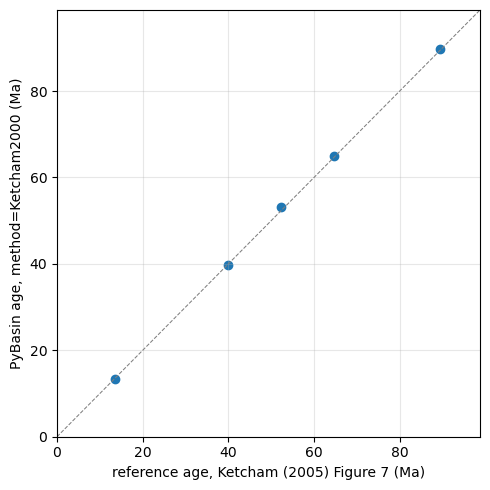

In [7]:
fig2, ax2 = plt.subplots(figsize=(5, 5))

ref_ages = np.array([reference[name]['age'] for name in histories])
model_ages = np.array([results[name]['age'] for name in histories])

max_age = max(ref_ages.max(), model_ages.max()) * 1.1
ax2.plot([0, max_age], [0, max_age], color='grey', ls='--', lw=0.75,
        label='1:1 line')
ax2.scatter(ref_ages, model_ages, color='C0', marker='o')

ax2.set_xlabel('reference age, Ketcham (2005) Figure 7 (Ma)')
ax2.set_ylabel('PyBasin age, method=Ketcham2000 (Ma)')
ax2.set_xlim(0, max_age)
ax2.set_ylim(0, max_age)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()

## Assessment

`method='Ketcham2000'` reproduces the ages read from Ketcham (2005) Figure 7 to within 0.4 to 1.8 percent for all five cases. This method was added specifically because PyBasin's original `method='Ketcham2007'` kinetics are a different, independently fitted model (fixed equation shape parameter beta = -1) from the Ketcham et al. (1999) kinetics Figure 7 was generated with (free beta, about -12); substituting one model's constants into the other's formula does not work, since the 2007 formula is structurally simpler and assumes beta = -1.

History 7d at Dpar 2.50 is the most demanding case: a moderate reheating that only partially resets a highly annealing resistant apatite, the regime where the free beta shape of the 1999 model matters most. PyBasin reproduces it to within 1.5 percent.

Remaining caveats: the new model was validated end to end only for `kinetic_parameter='Dpar'`, the option used throughout this benchmark. Its `Clwt` and bare `rmr0` kinetic parameter branches fall back to reusing the Ketcham (2007) conversions, since no independently published Ketcham (1999) specific formula for those was found; this is flagged in the code and should be treated as an approximation until a source is found. There is also no compiled Fortran implementation of the free beta model, so `method='Ketcham2000'` is always slower than the default Fortran accelerated `method='Ketcham2007'` path, though this has not been benchmarked for wall clock time here. Mean track lengths are not compared in this notebook, since Figure 7 only presents them as density plots, not as numeric values.